In [22]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_openml
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import Normalizer


# Implementing a KNN on the MNIST dataset
Using 784 features mnist ds. 

Download dataset,

In [23]:
mnist = fetch_openml("mnist_784", as_frame=False)

Split into train and test,

In [24]:
X_train, X_test, y_train, y_test = train_test_split(mnist.data, mnist.target, test_size=0.33, random_state=42)

Implement and train k-NN,

In [25]:
knn = make_pipeline(Normalizer(), KNeighborsClassifier(n_neighbors=6, weights="distance"))

In [26]:
knn.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('normalizer', ...), ('kneighborsclassifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](10,)","['0','1','2',...,'7','8','9']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,784
,"norm norm: {'l1', 'l2', 'max'}, default='l2'The norm to use to normalize each non zero sample. If norm='max'is used, values will be rescaled by the maximum of the absolutevalues.",'l2'
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array or a scipy.sparseCSR matrix).",True
Name,Type,Value
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,784


In [27]:
result=knn.predict(X_test)

Evaluate the ds, 

In [28]:
print('Accuracy :',accuracy_score(y_test,result))
print(classification_report(y_test,result))

Accuracy : 0.9752380952380952
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      2267
           1       0.97      0.99      0.98      2603
           2       0.98      0.97      0.98      2350
           3       0.98      0.96      0.97      2383
           4       0.99      0.97      0.98      2144
           5       0.99      0.96      0.97      2107
           6       0.98      1.00      0.99      2294
           7       0.97      0.97      0.97      2455
           8       0.98      0.96      0.97      2196
           9       0.95      0.97      0.96      2301

    accuracy                           0.98     23100
   macro avg       0.98      0.97      0.98     23100
weighted avg       0.98      0.98      0.98     23100



# Pipeline from raw image to prediction
Claude AI, have been used in this part mainly for the displaying of the samples. Inspired by these two articles: [https://www.mindee.com/blog/digit-recognition-python-opencv](https://www.mindee.com/blog/digit-recognition-python-opencv) and [https://docs.opencv.org/4.13.0/d8/d4b/tutorial_py_knn_opencv.html](https://docs.opencv.org/4.13.0/d8/d4b/tutorial_py_knn_opencv.html)

In [29]:
import cv2

In [30]:
# src: https://www.reddit.com/r/Handwriting/comments/zxjehf/i_have_always_struggled_with_my_fives_are_numbers/
reddit_sample = "./samples/randomsamplefromreddit.png"

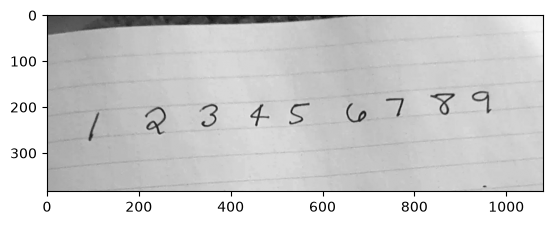

In [31]:
img = cv2.imread(reddit_sample)
img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
if img is None:
    raise FileNotFoundError("Impossible to load image.")
plt.imshow(img, cmap="gray")

Reduce noise using gaussian blur,

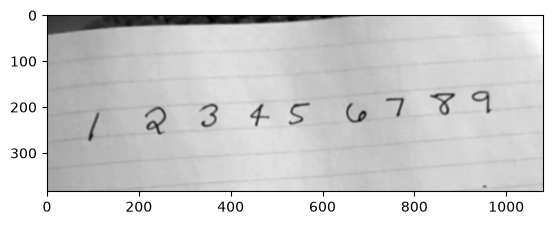

In [32]:
blurred = cv2.GaussianBlur(img, (9, 9), 0)
plt.imshow(blurred, cmap="gray")

Binarise the image,

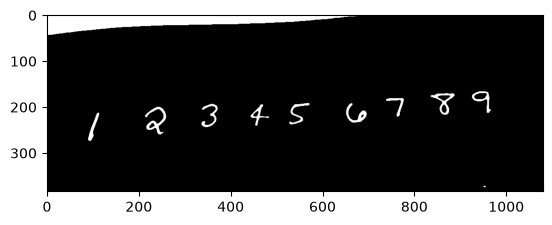

In [33]:
_, binary = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
plt.imshow(binary, cmap="gray")

Dilate image to fill spaces, 

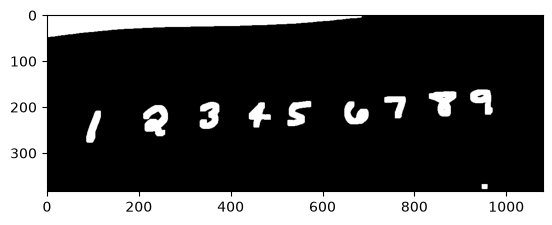

In [34]:
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
dilated = cv2.dilate(binary, kernel, iterations=2)
plt.imshow(dilated, cmap="gray")

Find contours, 

In [35]:
contours, _ = cv2.findContours(dilated, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

if not contours:
        raise ValueError("No numbers on the image.")

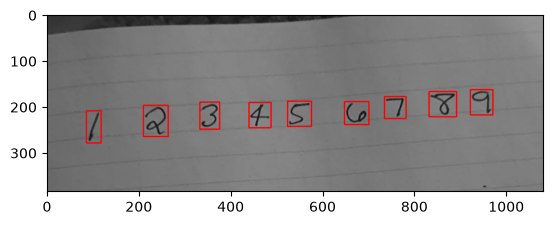

In [36]:
min_area = 200


boxes = []
for c in contours:
    if cv2.contourArea(c) <= min_area:
        continue                        # too small: noise
    x, y, w, h = cv2.boundingRect(c)
    if w >= 2 * h:
        continue                        # at least twice as wide as tall: not a digit
    boxes.append((x, y, w, h))

boxes.sort(key=lambda b: (b[1] // 50, b[0]))   # rows, then left to right

vis = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
for (x, y, w, h) in boxes:
    cv2.rectangle(vis, (x, y), (x + w, y + h), (255, 0, 0), 2)

plt.imshow(vis)

Extract samples from the image and transform in MNIST 28x28 shape, 

In [ ]:
# fully implemented using Claude
def to_mnist(d, stroke=0.0):
    """
    d:      crop with white ink on black background
    stroke: thickening relative to digit size (0 = none, try 0.03 to 0.08)
    """
    # 1. Tight crop around the ink, so padding no longer affects the scale
    ys, xs = np.nonzero(d)
    if len(xs) == 0:
        return np.zeros((28, 28), dtype=np.uint8)
    d = d[ys.min():ys.max() + 1, xs.min():xs.max() + 1]
    h, w = d.shape

    # 2. Optional thickening, proportional to the digit's size
    k = int(round(max(h, w) * stroke))
    if k > 0:
        d = cv2.dilate(d, cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (k, k)))
        d = np.pad(d, k)                    # dilation can grow past the crop
        ys, xs = np.nonzero(d)
        d = d[ys.min():ys.max() + 1, xs.min():xs.max() + 1]
        h, w = d.shape

    # 3. Fit in 20x20, keeping aspect ratio
    scale = 20.0 / max(h, w)
    resized = cv2.resize(d, (max(1, round(w * scale)), max(1, round(h * scale))),
                         interpolation=cv2.INTER_AREA)

    # 4. Paste in the middle of a 28x28 canvas
    canvas = np.zeros((28, 28), dtype=np.uint8)
    rh, rw = resized.shape
    y_off, x_off = (28 - rh) // 2, (28 - rw) // 2
    canvas[y_off:y_off + rh, x_off:x_off + rw] = resized

    # 5. Shift so the center of mass sits at the center, like MNIST
    m = cv2.moments(canvas)
    if m["m00"] > 0:
        cx, cy = m["m10"] / m["m00"], m["m01"] / m["m00"]
        M = np.float32([[1, 0, 14 - cx], [0, 1, 14 - cy]])
        canvas = cv2.warpAffine(canvas, M, (28, 28))
    return canvas

In [38]:
pad = 3
H, W = binary.shape

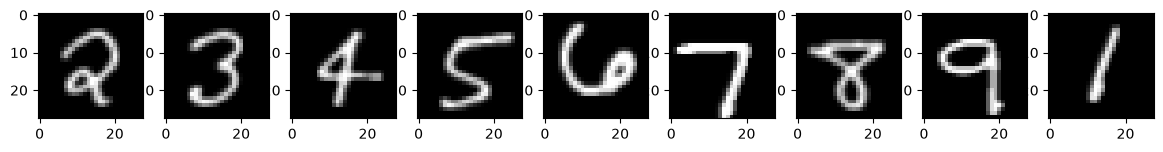

In [39]:
samples = []   # list of (28x28 digit, (x, y, w, h))
for (x, y, w, h) in boxes:
    x0, y0 = max(x - pad, 0), max(y - pad, 0)
    x1, y1 = min(x + w + pad, W), min(y + h + pad, H)
    samples.append((to_mnist(binary[y0:y1, x0:x1]), (x, y, w, h)))

n = len(samples)
fig, axes = plt.subplots(1, n, figsize=(1.6 * n, 2.2))
for ax, (digit, (x, y, w, h)) in zip(axes, samples):
    ax.imshow(digit, cmap="gray")

Predict the digit,

In [40]:
def predict_digit(digit, model=knn):
    """
    digit: 28x28 uint8 image, white digit on black background
    Returns (prediction, {digit: probability})
    """
    x = digit.reshape(1, -1).astype(np.float32)
    probs = model.predict_proba(x)[0]
    pred = int(model.classes_[np.argmax(probs)])
    probabilities = {int(c): float(p) for c, p in zip(model.classes_, probs)}
    return pred, probabilities

In [41]:
results = []   # list of (prediction, probabilities, box)
for digit, box in samples:
    pred, probs = predict_digit(digit)
    results.append((pred, probs, box))
    print(f"box {box}: predicted {pred}  (p = {probs[pred]:.2f})")

box (210, 196, 54, 68): predicted 2  (p = 1.00)
box (333, 189, 43, 59): predicted 3  (p = 1.00)
box (440, 190, 48, 55): predicted 4  (p = 1.00)
box (524, 187, 52, 55): predicted 5  (p = 1.00)
box (648, 188, 53, 50): predicted 6  (p = 1.00)
box (735, 177, 47, 48): predicted 7  (p = 1.00)
box (832, 166, 60, 55): predicted 8  (p = 0.84)
box (922, 162, 49, 55): predicted 9  (p = 1.00)
box (86, 208, 32, 70): predicted 1  (p = 1.00)


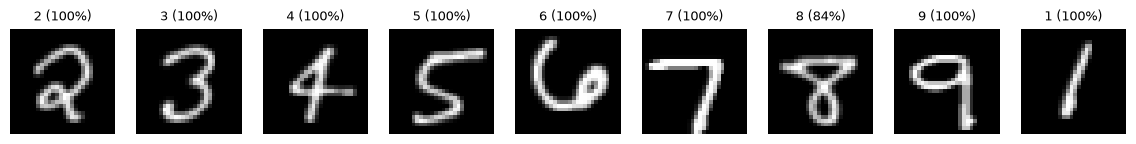

In [43]:
n = len(results)
fig, axes = plt.subplots(1, n, figsize=(1.6 * n, 2.2))
axes = np.atleast_1d(axes)
for ax, (digit, _), (pred, probs, _) in zip(axes, samples, results):
    ax.imshow(digit, cmap="gray")
    ax.set_title(f"{pred} ({probs[pred]:.0%})", fontsize=9)
    ax.axis("off")
plt.show()